
# 05 — Cookie Cats Experiment Analysis

**Product Pulse**

A/B test analysis of `gate_30` vs `gate_40` for retention and engagement.


In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.home() / "Desktop" / "resume_projects" / "ProductPulse"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "02_cleaned"

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("PROCESSED_DIR:", PROCESSED_DIR)

if not PROCESSED_DIR.exists():
    raise FileNotFoundError(
        f"Processed data folder not found: {PROCESSED_DIR}\n"
        "Run 02_data_cleaning_and_validation.ipynb first."
    )


PROJECT_ROOT : /Users/noopur/Desktop/resume_projects/ProductPulse
PROCESSED_DIR: /Users/noopur/Desktop/resume_projects/ProductPulse/data/processed/02_cleaned


In [2]:

from scipy.stats import chi2_contingency, mannwhitneyu, ttest_ind
COOKIE_PATH=PROCESSED_DIR/"cookie_cats_clean.parquet"
if not COOKIE_PATH.exists(): raise FileNotFoundError(COOKIE_PATH)
cats=pd.read_parquet(COOKIE_PATH); print("Shape:",cats.shape); display(cats.head())


Shape: (90189, 5)


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,0,0
1,337,gate_30,38,1,0
2,377,gate_40,165,1,0
3,483,gate_40,1,0,0
4,488,gate_40,179,1,1


## 1. Randomization and group sizes

In [3]:

group_sizes=cats["version"].value_counts().rename_axis("version").reset_index(name="users").sort_values("version")
group_sizes["share_pct"]=(100*group_sizes["users"]/group_sizes["users"].sum()).round(3); display(group_sizes)


,version,users,share_pct
1,gate_30,44700,49.563
0,gate_40,45489,50.437


## 2. Retention metrics

In [4]:

retention_summary=cats.groupby("version").agg(users=("userid","size"),retention_1_rate=("retention_1","mean"),retention_7_rate=("retention_7","mean"),mean_game_rounds=("sum_gamerounds","mean"),median_game_rounds=("sum_gamerounds","median")).reset_index()
retention_summary["retention_1_pct"]=100*retention_summary["retention_1_rate"]; retention_summary["retention_7_pct"]=100*retention_summary["retention_7_rate"]; display(retention_summary)


,version,users,retention_1_rate,retention_7_rate,mean_game_rounds,median_game_rounds,retention_1_pct,retention_7_pct
0,gate_30,44700,0.448188,0.190201,52.456264,17.0,44.818792,19.020134
1,gate_40,45489,0.442283,0.182,51.298776,16.0,44.228275,18.200004


In [5]:

def retention_test(df,column):
    contingency=pd.crosstab(df["version"],df[column]); chi2,p_value,dof,expected=chi2_contingency(contingency); rates=df.groupby("version")[column].mean(); g30=float(rates.get("gate_30",np.nan)); g40=float(rates.get("gate_40",np.nan)); return {"metric":column,"gate_30_rate":g30,"gate_40_rate":g40,"absolute_difference_gate40_minus_gate30":g40-g30,"relative_lift_pct":100*(g40-g30)/g30 if g30 else np.nan,"chi_square":chi2,"p_value":p_value}
retention_tests=pd.DataFrame([retention_test(cats,"retention_1"),retention_test(cats,"retention_7")]); display(retention_tests)


,metric,gate_30_rate,gate_40_rate,absolute_difference_gate40_minus_gate30,relative_lift_pct,chi_square,p_value
0,retention_1,0.448188,0.442283,-0.005905,-1.317566,3.159101,0.075505
1,retention_7,0.190201,0.182000,-0.008201,-4.311903,9.959087,0.001601


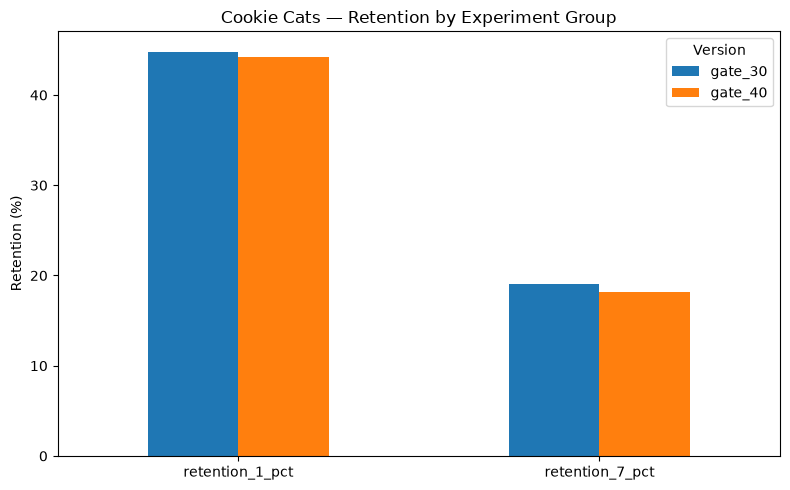

In [6]:

fig_retention,ax=plt.subplots(figsize=(8,5)); plot_retention=retention_summary.set_index("version")[["retention_1_pct","retention_7_pct"]].T; plot_retention.plot(kind="bar",ax=ax); ax.set_title("Cookie Cats — Retention by Experiment Group"); ax.set_ylabel("Retention (%)"); ax.set_xlabel(""); ax.legend(title="Version"); ax.tick_params(axis="x",rotation=0); fig_retention.tight_layout(); plt.show()


## 3. Game-round engagement

In [7]:

g30=cats.loc[cats["version"]=="gate_30","sum_gamerounds"]; g40=cats.loc[cats["version"]=="gate_40","sum_gamerounds"]
welch=ttest_ind(g30,g40,equal_var=False,nan_policy="omit"); mw=mannwhitneyu(g30,g40,alternative="two-sided")
rounds_test=pd.DataFrame([{"gate_30_mean":g30.mean(),"gate_40_mean":g40.mean(),"gate_30_median":g30.median(),"gate_40_median":g40.median(),"mean_difference_gate40_minus_gate30":g40.mean()-g30.mean(),"welch_t_stat":welch.statistic,"welch_t_p_value":welch.pvalue,"mann_whitney_u":mw.statistic,"mann_whitney_p_value":mw.pvalue}]); display(rounds_test)


,gate_30_mean,gate_40_mean,gate_30_median,gate_40_median,mean_difference_gate40_minus_gate30,welch_t_stat,welch_t_p_value,mann_whitney_u,mann_whitney_p_value
0,52.456264,51.298776,17.0,16.0,-1.157488,0.885437,0.375924,1.024331e+09,0.050209


In [8]:

percentile_table=cats.groupby("version")["sum_gamerounds"].quantile([0.50,0.75,0.90,0.95,0.99]).unstack().reset_index().rename(columns={0.50:"p50",0.75:"p75",0.90:"p90",0.95:"p95",0.99:"p99"}); display(percentile_table)


,version,p50,p75,p90,p95,p99
0,gate_30,17.0,50.0,135.0,222.0,493.00
1,gate_40,16.0,52.0,134.0,220.0,492.12


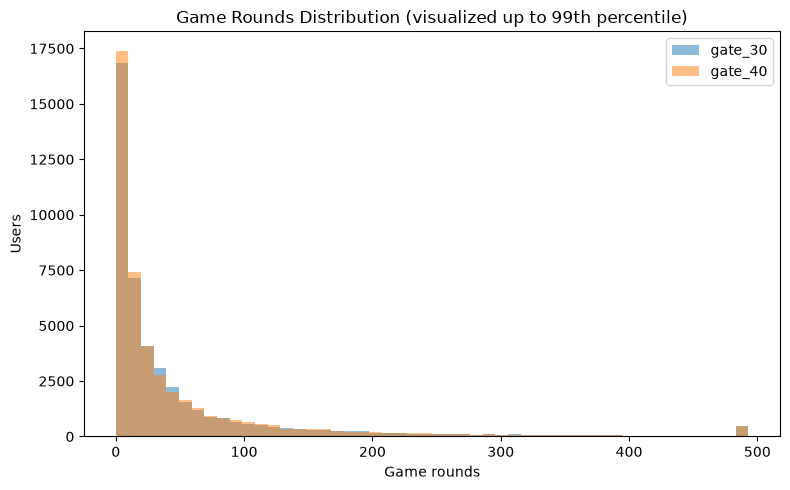

In [9]:

fig_rounds,ax=plt.subplots(figsize=(8,5)); plot_cap=cats["sum_gamerounds"].quantile(0.99)
for version in ["gate_30","gate_40"]:
    vals=cats.loc[cats["version"]==version,"sum_gamerounds"].clip(upper=plot_cap); ax.hist(vals,bins=50,alpha=0.5,label=version)
ax.set_title("Game Rounds Distribution (visualized up to 99th percentile)"); ax.set_xlabel("Game rounds"); ax.set_ylabel("Users"); ax.legend(); fig_rounds.tight_layout(); plt.show()


## 4. Experiment conclusion

In [10]:

experiment_conclusion=retention_tests[["metric","gate_30_rate","gate_40_rate","absolute_difference_gate40_minus_gate30","relative_lift_pct","p_value"]].copy(); experiment_conclusion["statistically_significant_0_05"]=experiment_conclusion["p_value"]<0.05; display(experiment_conclusion)


,metric,gate_30_rate,gate_40_rate,absolute_difference_gate40_minus_gate30,relative_lift_pct,p_value,statistically_significant_0_05
0,retention_1,0.448188,0.442283,-0.005905,-1.317566,0.075505,False
1,retention_7,0.190201,0.182000,-0.008201,-4.311903,0.001601,True


## 5. Save compact results

In [11]:

RESULTS_DIR=PROJECT_ROOT/"results"/"05_cookie_cats_experiment_analysis"; TABLES_DIR=RESULTS_DIR/"tables"; FIGURES_DIR=RESULTS_DIR/"figures"; TABLES_DIR.mkdir(parents=True,exist_ok=True); FIGURES_DIR.mkdir(parents=True,exist_ok=True)
RESULT_TABLES={"group_sizes":group_sizes,"retention_summary":retention_summary,"retention_tests":retention_tests,"rounds_test":rounds_test,"game_round_percentiles":percentile_table,"experiment_conclusion":experiment_conclusion}
RESULT_FIGURES={"retention_by_group":fig_retention,"game_round_distribution":fig_rounds}
for name,table in RESULT_TABLES.items(): table.to_csv(TABLES_DIR/f"{name}.csv",index=False)
for name,fig in RESULT_FIGURES.items(): fig.savefig(FIGURES_DIR/f"{name}.png",dpi=200,bbox_inches="tight")
print(f"Tables saved : {len(RESULT_TABLES)}"); print(f"Figures saved: {len(RESULT_FIGURES)}"); print("Saved to:",RESULTS_DIR)


Tables saved : 6
Figures saved: 2
Saved to: /Users/noopur/Desktop/resume_projects/ProductPulse/results/05_cookie_cats_experiment_analysis
